In [12]:
import jax.numpy as jnp
from jax import jit
import matplotlib.pyplot as plt
import jax.numpy as jnp
from jax import vmap, lax
import numpy as np
from pathlib import Path
import jax

import typing
import h5py
import pandas as pd

import os
import blackjax
import jax.numpy as jnp
import jax.random as random
from tabulate import tabulate
from dataclasses import dataclass
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.gridspec import GridSpecFromSubplotSpec

# Change the used font to the same LaTeX uses for consistency
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

import sys
import os


# Add the root project directory to the system path
sys.path.append(os.path.abspath(".."))
from ssps.ssp_data import SSPData

filename = '/Users/amanda/Desktop/PhD/Tools/ceridwen/data/test_data/ssp_data.h5'
ssp_data = SSPData.load(filename)


spec_df = pd.read_csv('/Users/amanda/Desktop/PhD/Tools/ceridwen/data/test_data/spectra.csv')
wave = jnp.array(spec_df['wave'])

In [13]:
from sedpy_jax.attenuation import calzetti, drude


In [ ]:
import jax.numpy as jnp
from jax import vmap
from sedpy_jax.attenuation_dust import ATTENUATION_LAWS


class Dust:
    """
    JAX-compatible modular dust model that supports multiple attenuation laws per bin.

    Use this to compute attenuation curves given a binning in stellar age
    and a choice of fixed attenuation law per bin. Parameter fitting
    is only applied to the `fit_params` dictionary passed at runtime.

    Call `Dust.describe_attenuation_laws()` to list all available models.
    """

    def __init__(self, bin_edges, laws, diffuse_law="kriek_conroy"):
        """
        Parameters:
            bin_edges (list of tuple): Age bins in Myr.
            laws (list of str): Attenuation law names (e.g., 'smc', 'kriek_conroy') for each bin.
            diffuse_law (str): Law to apply multiplicatively as diffuse component.
        """
        assert len(bin_edges) == len(laws), "Must have one dust law per bin"
        self.bin_edges = jnp.array(bin_edges)
        self.num_bins = len(bin_edges)
        self.laws = laws
        self.diffuse_law = diffuse_law

        self.law_funcs = [self._get_law_fn(name) for name in laws]
        self.law_params = [self._get_law_params(name) for name in laws]

        if diffuse_law is not None:
            self.diffuse_params = self._get_law_params(diffuse_law)
            self.diffuse_fn = self._get_law_fn(diffuse_law)
            self.compute_attenuation = self._compute_with_diffuse
        else:
            self.diffuse_params = None
            self.diffuse_fn = None
            self.compute_attenuation = self._compute_no_diffuse

    def _get_law_fn(self, name):
        try:
            return ATTENUATION_LAWS[name]["func"]
        except KeyError:
            raise ValueError(f"Unknown attenuation law: '{name}'. Please add '{name}' to the sedpy_jax.attenuation module, as a function and as an entry in the ATTENUATION_LAWS dictionary.")
    
    def _get_law_params(self, name):
        try:
            return ATTENUATION_LAWS[name]["params"]
        except KeyError:
            raise ValueError(f"Unknown attenuation law: '{name}'. Please add '{name}' to the sedpy_jax.attenuation module, as a function and as an entry in the ATTENUATION_LAWS dictionary.")
        
    def __repr__(self):
        def format_array(arr):
            return "\n    " + "\n    ".join(map(str, arr))

        info = [
            "Dust Model Configuration",
            "=" * 60,
            f"Number of bins          : {self.num_bins}",
            f"Bin edges (Myr)         : {format_array(self.bin_edges)}",
            f"Dust laws               : {', '.join(self.laws)}",
            f"Dust parameters        : {', '.join(map(str, self.law_params))}",
            f"Diffuse dust law        : {self.diffuse_law}",
            f"Diffuse parameters      : {self.diffuse_params}",
            "-" * 60,
        ]

        for i, lawname in enumerate(self.laws):
            lawinfo = ATTENUATION_LAWS.get(lawname, {})
            doc = lawinfo.get("doc", "No description.")
            defaults = lawinfo.get("defaults", {})
            params = lawinfo.get("params", {})
            info.append(f"Bin {i} → {lawname}")
            info.append(f"  Description: {doc}")
            for p, d in params.items():
                info.append(f"    {p:10s}: {d}")
            info.append(f"  Defaults: {defaults}")
            info.append("-" * 60)

        return "\n".join(info)
    
    def _compute_no_diffuse(self, wave, fit_params):
        """
        Compute bin-wise attenuation curves using the provided parameters.

        Parameters:
            wave (jnp.ndarray): Wavelength array in Angstroms.
            fit_params (dict): Parameters for the attenuation laws.
        Returns:
            jnp.ndarray: shape (num_bins, len(wave)) attenuation per bin
        """
        def curve_fn(i, wave, fit_params):
            def wrapped_law_fn(idx):
                return self.law_funcs[idx](wave, **fit_params)
            return lax.switch(i, [lambda: f(wave, **fit_params) for f in self.law_funcs])

        curves = vmap(curve_fn, in_axes=(0, None, None))(jnp.arange(self.num_bins), wave, fit_params)

        return curves
    
    def _compute_with_diffuse(self, wave, fit_params):
        """
        Compute bin-wise attenuation curves using the provided parameters.

        Parameters:
            wave (jnp.ndarray): Wavelength array in Angstroms.
            fit_params (dict): Parameters for the attenuation laws. Must include a subdictionary "diffuse_params" for the diffuse law.
        Returns:
            jnp.ndarray: shape (num_bins, len(wave)) attenuation per bin
        """
        def curve_fn(i, wave, fit_params):
            def wrapped_law_fn(idx):
                return self.law_funcs[idx](wave, **fit_params)
            return lax.switch(i, [lambda: f(wave, **fit_params) for f in self.law_funcs])

        curves = vmap(curve_fn, in_axes=(0, None, None))(jnp.arange(self.num_bins), wave, fit_params)

        diffuse_curve = self.diffuse_fn(
                wave, **fit_params["diffuse_params"])
        
        curves *= diffuse_curve

        return curves
    
    @staticmethod
    def describe_attenuation_laws():
        """
        Print all available dust laws with descriptions and parameter metadata.
        """
        print("=" * 70)
        print("Available Dust Attenuation Laws in sedpy_jax:\n")
        for name, info in ATTENUATION_LAWS.items():
            print(f"• {name}")
            print(f"  Description: {info.get('doc', 'No description.')}")
            print("  Parameters:")
            for param, desc in info.get("params", {}).items():
                print(f"    {param:12s}: {desc}")
            print("-" * 70)

    def get_default_fit_params(self):
        """
        Return a dictionary of default fit parameters based on chosen dust laws.
        Returns:
            dict: {
                'tau': jnp.array([...]),
                'index': jnp.array([...]),
                'diffuse_tau': float,
                'diffuse_index': float
            }
        """

        defaults = {}

        for law in self.laws:
            for v, p in ATTENUATION_LAWS[law].get("defaults", {}).items():
                defaults[v] = p
            

        diffuse_defaults = ATTENUATION_LAWS[self.diffuse_law].get("defaults", {})
        defaults['diffuse_params'] = diffuse_defaults

        return defaults
    
def modify_function(func, number, defaults_dict=None):
    import inspect

    func_name = func.__name__
    sig = inspect.signature(func)

    new_func_name = f"{func_name}{number}"

    new_params = []
    call_params = []
    original_names = []
    for name, param in sig.parameters.items():
        if param.kind == param.VAR_KEYWORD:
            continue
        new_name = f"{name}{number}"
        original_names.append(name)

        if param.default is not inspect.Parameter.empty:
            default_val = repr(param.default)
        elif defaults_dict and name in defaults_dict:
            default_val = repr(defaults_dict[name])
        else:
            default_val = None

        if default_val is not None:
            new_params.append(f"{new_name}={default_val}")
        else:
            new_params.append(new_name)

        call_params.append(f"{name}={new_name}")

    arg_str = ", ".join(new_params + ["**kwargs"])
    call_str = f"{func_name}({', '.join(call_params)}, **filtered_kwargs)"

    func_def = f"""
def {new_func_name}({arg_str}):
    filtered_kwargs = {{k: v for k, v in kwargs.items() if k not in {original_names!r}}}
    return {call_str}
"""

    local_ns = {func_name: func}
    exec(func_def, local_ns)
    return local_ns[new_func_name]

In [162]:
import jax.numpy as jnp
from jax import vmap
from collections import defaultdict
from sedpy_jax.attenuation_dust import ATTENUATION_LAWS


class Dust:
    """
    JAX-compatible modular dust model that supports multiple attenuation laws per bin.

    Use this to compute attenuation curves given a binning in stellar age
    and a choice of fixed attenuation law per bin. Parameter fitting
    is only applied to the `fit_params` dictionary passed at runtime.

    Call `Dust.describe_attenuation_laws()` to list all available models.
    """

    def __init__(self, bin_edges, laws, diffuse_law="kriek_conroy"):
        """
        Parameters:
            bin_edges (list of tuple): Age bins in Myr.
            laws (list of str): Attenuation law names (e.g., 'smc', 'kriek_conroy') for each bin.
            diffuse_law (str): Law to apply multiplicatively as diffuse component.
        """
        assert len(bin_edges) == len(laws), "Must have one dust law per bin"
        self.bin_edges = jnp.array(bin_edges)
        self.num_bins = len(bin_edges)
        self.laws = laws
        self.diffuse_law = diffuse_law

        self.law_names_resolved = []
        law_name_counter = defaultdict(int)
        law_occurrences = {name: laws.count(name) for name in set(laws)}

        self.law_funcs = []
        self.law_params = []

        for name in laws:
            count = law_name_counter[name]
            law_name_counter[name] += 1

            law_entry = ATTENUATION_LAWS[name]
            base_func = law_entry["func"]
            defaults = law_entry.get("defaults", {})
            params = law_entry.get("params", {})
            doc = law_entry.get("doc", "")

            if law_occurrences[name] == 1:
                # Only used once → keep original name and function
                resolved_name = name
                func = base_func
                param_dict = self._get_law_params(name)
            else:
                # Used multiple times → rename function and parameters
                number = count + 1
                resolved_name = f"{name}{number}"
                func = modify_function(base_func, number, defaults)

                # Register modified version
                ATTENUATION_LAWS[resolved_name] = {
                    "func": func,
                    "defaults": {f"{k}{number}": v for k, v in defaults.items()},
                    "params": {f"{k}{number}": d for k, d in params.items()},
                    "doc": doc
                }

                # Notify user of renaming
                renamed_keys = [f"{k}{number}" for k in defaults.keys()]
                ignored_keys = list(defaults.keys())
                print(f"[dust setup] Law '{name}' is used multiple times. Registered as '{resolved_name}'.")
                print(f"             Use parameters: {', '.join(renamed_keys)}")
                print(f"             Parameters like {', '.join(ignored_keys)} will be ignored, unless in the diffuse_params dict.")

                # Rename parameters
                param_dict = self._get_law_params(name)
                param_dict = {f"{k}{number}": v for k, v in param_dict.items()}

            self.law_names_resolved.append(resolved_name)
            self.law_funcs.append(func)
            self.law_params.append(param_dict)

        if diffuse_law is not None:
            self.diffuse_params = self._get_law_params(diffuse_law)
            self.diffuse_fn = self._get_law_fn(diffuse_law)
            self.compute_attenuation = self._compute_with_diffuse
        else:
            self.diffuse_params = None
            self.diffuse_fn = None
            self.compute_attenuation = self._compute_no_diffuse

    def _get_law_fn(self, name):
        try:
            return ATTENUATION_LAWS[name]["func"]
        except KeyError:
            raise ValueError(f"Unknown attenuation law: '{name}'. Please add '{name}' to the sedpy_jax.attenuation module, as a function and as an entry in the ATTENUATION_LAWS dictionary.")
    
    def _get_law_params(self, name):
        try:
            return ATTENUATION_LAWS[name]["params"]
        except KeyError:
            raise ValueError(f"Unknown attenuation law: '{name}'. Please add '{name}' to the sedpy_jax.attenuation module, as a function and as an entry in the ATTENUATION_LAWS dictionary.")
        
    def __repr__(self):
        def format_array(arr):
            return "\n    " + "\n    ".join(map(str, arr))

        info = [
            "Dust Model Configuration",
            "=" * 60,
            f"Number of bins          : {self.num_bins}",
            f"Bin edges (Myr)         : {format_array(self.bin_edges)}",
            f"Dust laws               : {', '.join(self.laws)}",
            f"Dust parameters        : {', '.join(map(str, self.law_params))}",
            f"Diffuse dust law        : {self.diffuse_law}",
            f"Diffuse parameters      : {self.diffuse_params}",
            "-" * 60,
        ]

        for i, lawname in enumerate(self.laws):
            lawinfo = ATTENUATION_LAWS.get(lawname, {})
            doc = lawinfo.get("doc", "No description.")
            defaults = lawinfo.get("defaults", {})
            params = lawinfo.get("params", {})
            info.append(f"Bin {i} → {lawname}")
            info.append(f"  Description: {doc}")
            for p, d in params.items():
                info.append(f"    {p:10s}: {d}")
            info.append(f"  Defaults: {defaults}")
            info.append("-" * 60)

        return "\n".join(info)
    
    def _compute_no_diffuse(self, wave, fit_params):
        """
        Compute bin-wise attenuation curves using the provided parameters.

        Parameters:
            wave (jnp.ndarray): Wavelength array in Angstroms.
            fit_params (dict): Parameters for the attenuation laws.
        Returns:
            jnp.ndarray: shape (num_bins, len(wave)) attenuation per bin
        """
        def curve_fn(i, wave, fit_params):
            def wrapped_law_fn(idx):
                return self.law_funcs[idx](wave, **fit_params)
            return lax.switch(i, [lambda: f(wave, **fit_params) for f in self.law_funcs])

        curves = vmap(curve_fn, in_axes=(0, None, None))(jnp.arange(self.num_bins), wave, fit_params)

        return curves
    
    def _compute_with_diffuse(self, wave, fit_params):
        """
        Compute bin-wise attenuation curves using the provided parameters.

        Parameters:
            wave (jnp.ndarray): Wavelength array in Angstroms.
            fit_params (dict): Parameters for the attenuation laws. Must include a subdictionary "diffuse_params" for the diffuse law.
        Returns:
            jnp.ndarray: shape (num_bins, len(wave)) attenuation per bin
        """
        def curve_fn(i, wave, fit_params):
            def wrapped_law_fn(idx):
                return self.law_funcs[idx](wave, **fit_params)
            return lax.switch(i, [lambda: f(wave, **fit_params) for f in self.law_funcs])

        curves = vmap(curve_fn, in_axes=(0, None, None))(jnp.arange(self.num_bins), wave, fit_params)

        diffuse_curve = self.diffuse_fn(
                wave, **fit_params["diffuse_params"])
        
        curves *= diffuse_curve

        return curves
    
    @staticmethod
    def describe_attenuation_laws():
        """
        Print all available dust laws with descriptions and parameter metadata.
        """
        print("=" * 70)
        print("Available Dust Attenuation Laws in sedpy_jax:\n")
        for name, info in ATTENUATION_LAWS.items():
            print(f"• {name}")
            print(f"  Description: {info.get('doc', 'No description.')}")
            print("  Parameters:")
            for param, desc in info.get("params", {}).items():
                print(f"    {param:12s}: {desc}")
            print("-" * 70)

    def get_default_fit_params(self):
        """
        Return a dictionary of default fit parameters based on chosen dust laws.
        Returns:
            dict: {
                'tau': jnp.array([...]),
                'index': jnp.array([...]),
                'diffuse_tau': float,
                'diffuse_index': float
            }
        """

        defaults = {}

        for law in self.law_names_resolved:
            for v, p in ATTENUATION_LAWS[law].get("defaults", {}).items():
                defaults[v] = p
            

        diffuse_defaults = ATTENUATION_LAWS[self.diffuse_law].get("defaults", {})
        defaults['diffuse_params'] = diffuse_defaults

        return defaults
    
def modify_function(func, number, defaults_dict=None):
    import inspect

    func_name = func.__name__
    sig = inspect.signature(func)

    new_func_name = f"{func_name}{number}"

    new_params = []
    call_params = []
    original_names = []
    for name, param in sig.parameters.items():
        if param.kind == param.VAR_KEYWORD:
            continue
        new_name = f"{name}{number}" if name != "wave" else f"wave"
        original_names.append(name)

        if param.default is not inspect.Parameter.empty:
            default_val = repr(param.default)
        elif defaults_dict and name in defaults_dict:
            default_val = repr(defaults_dict[name])
        else:
            default_val = None

        if default_val is not None:
            new_params.append(f"{new_name}={default_val}")
        else:
            new_params.append(new_name)

        call_params.append(f"{name}={new_name}")

    arg_str = ", ".join(new_params + ["**kwargs"])
    call_str = f"{func_name}({', '.join(call_params)}, **filtered_kwargs)"

    func_def = f"""
def {new_func_name}({arg_str}):
    filtered_kwargs = {{k: v for k, v in kwargs.items() if k not in {original_names!r}}}
    return {call_str}
"""

    local_ns = {func_name: func}
    exec(func_def, local_ns)
    return local_ns[new_func_name]

In [163]:
ATTENUATION_LAWS

{'smc': {'func': <function sedpy_jax.attenuation_dust.smc(wave, tau_smc=1.0, **kwargs)>,
  'params': {'tau_smc': 'Optical depth at 1500 Å'},
  'defaults': {'tau_smc': 1.0},
  'doc': 'SMC extinction curve from Gordon et al. (2003), appropriate for low-metallicity environments.'},
 'lmc': {'func': <function sedpy_jax.attenuation_dust.lmc(wave, tau_lmc=1.0, **kwargs)>,
  'params': {'tau_lmc': 'Optical depth at 1500 Å'},
  'defaults': {'tau_lmc': 1.0},
  'doc': 'LMC extinction curve following Gordon et al. (2003), intermediate dust properties.'},
 'kriek_conroy': {'func': <function sedpy_jax.attenuation_dust.kriek_conroy(wave, tau_kc=1.0, dust_index=0.0, **kwargs)>,
  'params': {'tau_kc': 'Amplitude of attenuation at 5500 Å',
   'dust_index': 'Power-law slope around the Calzetti curve'},
  'defaults': {'tau_kc': 1.0, 'dust_index': 0.0},
  'doc': 'Flexible attenuation curve with variable slope around Calzetti, Kriek & Conroy (2013).'},
 'powerlaw': {'func': <function sedpy_jax.attenuation_d

In [164]:
[(v, p) for v, p in ATTENUATION_LAWS['smc'].get("defaults", {}).items()]

[('tau_smc', 1.0)]

In [165]:
dust = Dust(
    bin_edges=[(0, 4), (4, 10), (10, 12), (12, jnp.inf)],
    laws=["smc", "smc", "kriek_conroy", "kriek_conroy"],
    diffuse_law="kriek_conroy"
)

dust.law_funcs

[dust setup] Law 'smc' is used multiple times. Registered as 'smc1'.
             Use parameters: tau_smc1
             Parameters like tau_smc will be ignored, unless in the diffuse_params dict.
[dust setup] Law 'smc' is used multiple times. Registered as 'smc2'.
             Use parameters: tau_smc2
             Parameters like tau_smc will be ignored, unless in the diffuse_params dict.
[dust setup] Law 'kriek_conroy' is used multiple times. Registered as 'kriek_conroy1'.
             Use parameters: tau_kc1, dust_index1
             Parameters like tau_kc, dust_index will be ignored, unless in the diffuse_params dict.
[dust setup] Law 'kriek_conroy' is used multiple times. Registered as 'kriek_conroy2'.
             Use parameters: tau_kc2, dust_index2
             Parameters like tau_kc, dust_index will be ignored, unless in the diffuse_params dict.


[<function smc1(wave, tau_smc1=1.0, **kwargs)>,
 <function smc2(wave, tau_smc2=1.0, **kwargs)>,
 <function kriek_conroy1(wave, tau_kc1=1.0, dust_index1=0.0, **kwargs)>,
 <function kriek_conroy2(wave, tau_kc2=1.0, dust_index2=0.0, **kwargs)>]

In [161]:
defaults = dust.get_default_fit_params()

print(defaults)

{'tau_smc1': 1.0, 'tau_smc2': 1.0, 'tau_kc1': 1.0, 'dust_index1': 0.0, 'tau_kc2': 1.0, 'dust_index2': 0.0, 'diffuse_params': {'tau_kc': 1.0, 'dust_index': 0.0}}


In [119]:
fit_params = {
    "tau_smc1": 0.3,
    "tau_kc": 0.5,
    "tau_smc": 5,
    "diffuse_params": {"tau_kc": 0.5, "dust_index": -0.7},
}

dust.compute_attenuation(wave, fit_params)

Array([[2.9124227e+08, 2.3179488e+08, 1.9983029e+08, ..., 4.8209339e-27,
        4.6163351e-27, 4.4200940e-27],
       [2.9124227e+08, 2.3179488e+08, 1.9983029e+08, ..., 4.8209339e-27,
        4.6163351e-27, 4.4200940e-27],
       [2.9124227e+08, 2.3179488e+08, 1.9983029e+08, ..., 4.8209339e-27,
        4.6163351e-27, 4.4200940e-27]], dtype=float32)

In [108]:
from sedpy_jax.attenuation_dust import kriek_conroy

In [109]:
kriek_conroy(wave, **fit_params)

Array([4.0612971e+03, 3.6645422e+03, 3.4276672e+03, ..., 1.3338666e-12,
       1.3094774e-12, 1.2854938e-12], dtype=float32)

In [110]:
def modify_function(func, number, defaults_dict=None):
    import inspect

    func_name = func.__name__
    sig = inspect.signature(func)

    new_func_name = f"{func_name}{number}"

    new_params = []
    call_params = []
    original_names = []
    for name, param in sig.parameters.items():
        if param.kind == param.VAR_KEYWORD:
            continue
        new_name = f"{name}{number}"
        original_names.append(name)

        if param.default is not inspect.Parameter.empty:
            default_val = repr(param.default)
        elif defaults_dict and name in defaults_dict:
            default_val = repr(defaults_dict[name])
        else:
            default_val = None

        if default_val is not None:
            new_params.append(f"{new_name}={default_val}")
        else:
            new_params.append(new_name)

        call_params.append(f"{name}={new_name}")

    arg_str = ", ".join(new_params + ["**kwargs"])
    call_str = f"{func_name}({', '.join(call_params)}, **filtered_kwargs)"

    func_def = f"""
def {new_func_name}({arg_str}):
    filtered_kwargs = {{k: v for k, v in kwargs.items() if k not in {original_names!r}}}
    return {call_str}
"""

    local_ns = {func_name: func}
    exec(func_def, local_ns)
    return local_ns[new_func_name]

In [111]:
kriek_conroy1 = modify_function(kriek_conroy, 1)

In [112]:
kriek_conroy1

<function kriek_conroy1(wave1, tau_kc1=1.0, dust_index1=0.0, **kwargs)>

In [113]:
fit_params

{'tau_smc': 0.3,
 'tau_kc': 0.5,
 'tau_kc1': 5,
 'diffuse_params': {'tau_kc': 0.5, 'dust_index': -0.7}}

(-100.0, 20000.0)

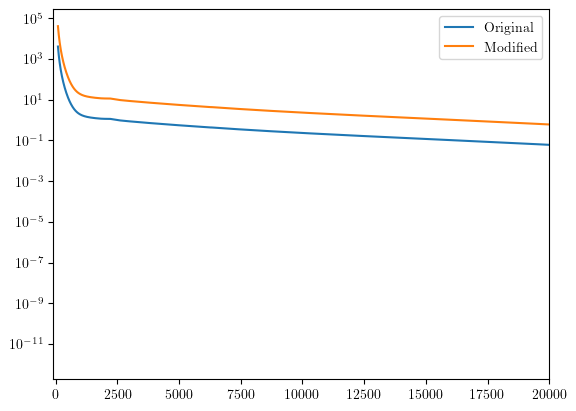

In [114]:
plt.plot(wave, kriek_conroy(wave, **fit_params), label='Original')
plt.plot(wave, kriek_conroy1(wave, **fit_params), label='Modified')
plt.legend()
plt.yscale('log')
plt.xlim(-100, 20000)